**Обучение LSTM-автоэнкодера**

**Этапы:**
1. Формирование скользящих окон (ЭЦН: 60×9, ШГН: 100×9) (Timestep × число признаков), а длительность окна в минутах берётся из спектрального анализа (ЭЦН: один цикл, ШГН: два цикла)
2. Обучение LSTM-автоэнкодера (encoder → latent space → decoder)

**Вход:**
- data/processed/ecn_train.csv, ecn_val.csv, ecn_test.csv, scaler_ecn.pkl
- data/processed/shgn_train.csv, shgn_val.csv, shgn_test.csv, scaler_shgn.pkl

**Важно:** Данные ШГН уже объединены (скважины 134+135) и нормализованы одним scaler'ом.

**Выход:**
- models/ecn/ (encoder.pth, decoder.pth, metadata.json, scaler.pkl)
- models/shgn/ (encoder.pth, decoder.pth, metadata.json, scaler.pkl)

In [69]:
import json
import pickle
from copy import deepcopy
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

### 1: Загрузка данных из /data/processed

In [15]:
DATA_DIR = Path("../data/processed")
FEATURE_COLUMNS = [
    "us_center",
    "us_periph",
    "gas_center",
    "gas_periph",
    "temp",
    "water_center",
    "water_periph",
    "gas_integral",
    "water_integral",
]

In [17]:
df_ecn_train = pd.read_csv(DATA_DIR / "ecn_train.csv", parse_dates=["timestamp"])
df_ecn_val = pd.read_csv(DATA_DIR / "ecn_val.csv", parse_dates=["timestamp"])
df_ecn_test = pd.read_csv(DATA_DIR / "ecn_test.csv", parse_dates=["timestamp"])

df_shgn_train = pd.read_csv(DATA_DIR / "shgn_train.csv", parse_dates=["timestamp"])
df_shgn_val = pd.read_csv(DATA_DIR / "shgn_val.csv", parse_dates=["timestamp"])
df_shgn_test = pd.read_csv(DATA_DIR / "shgn_test.csv", parse_dates=["timestamp"])

In [18]:
with open(DATA_DIR / "scaler_ecn.pkl", "rb") as f:
    scaler_ecn = pickle.load(f)

with open(DATA_DIR / "scaler_shgn.pkl", "rb") as f:
    scaler_shgn = pickle.load(f)

In [6]:
print("\nЭЦН:")
print(f"  Train: {len(df_ecn_train):,} точек")
print(f"  Val:   {len(df_ecn_val):,} точек")
print(f"  Test:  {len(df_ecn_test):,} точек")

print("\nШГН (скважины 134+135 объединённые):")
print(f"  Train: {len(df_shgn_train):,} точек")
print(f"  Val:   {len(df_shgn_val):,} точек")
print(f"  Test:  {len(df_shgn_test):,} точек")

print(f"\nПризнаков: {len(FEATURE_COLUMNS)}")
print(f"Колонки: {list(df_ecn_train.columns)}")


ЭЦН:
  Train: 33,377 точек
  Val:   4,168 точек
  Test:  4,172 точек

ШГН (скважины 134+135 объединённые):
  Train: 82,736 точек
  Val:   10,331 точек
  Test:  10,341 точек

Признаков: 9
Колонки: ['us_center', 'us_periph', 'gas_center', 'gas_periph', 'temp', 'water_center', 'water_periph', 'outlet_num', 'gas_integral', 'water_integral', 'timestamp', 'well']


In [19]:
print("\nПроверка нормализации:")
print(
    f"ЭЦН train - mean: {df_ecn_train[FEATURE_COLUMNS].mean().mean():.3f}, std: {df_ecn_train[FEATURE_COLUMNS].std().mean():.3f}"
)
print(
    f"ШГН train - mean: {df_shgn_train[FEATURE_COLUMNS].mean().mean():.3f}, std: {df_shgn_train[FEATURE_COLUMNS].std().mean():.3f}"
)

print("\nПропуски:")
print(f"ЭЦН: {df_ecn_train[FEATURE_COLUMNS].isnull().sum().sum()}")
print(f"ШГН: {df_shgn_train[FEATURE_COLUMNS].isnull().sum().sum()}")


Проверка нормализации:
ЭЦН train - mean: -0.043, std: 1.023
ШГН train - mean: -0.017, std: 1.073

Пропуски:
ЭЦН: 0
ШГН: 0


### 2: Формирование скользящих окон

Преобразуем временные ряды в матрицы окон для обучения автоэнкодера.

Параметры:
- ЭЦН: окно 60 точек (10 минут), шаг 1 точка (10 сек)
- ШГН: окно 100 точек (17 минут, ~2 цикла по 7 мин), шаг 1 точка (10 сек)

Результат: матрицы 60×9 / 100×9 (время × параметры)

Для ЭЦН явной периодичности, сравнимой с циклом штангового насоса, по графикам временных рядов не наблюдается, поэтому спектральный анализ не выполнялся. Длину окна выбирали эмпирически: при слишком коротких окнах модель плохо различала нормальную работу и аномалии, при слишком длинных — росла размерность и время обучения без заметного улучшения качества реконструкции. В итоге выбрано окно 60 отсчётов (10 минут) как компромисс между объёмом контекста и сложностью модели.

Для ШГН был выполнен спектральный анализ по признакам water_center, gas_center, us_center, который показал доминирующие периоды 6–8 минут. На этой основе практическим путём выбрано окно 100 отсчётов (~17 минут), покрывающее 2 цикла работы.

In [22]:
WINDOW_SIZE_ECN = 60
WINDOW_SIZE_SHGN = 100
STEP = 1

def create_sliding_windows(df, feature_columns, window_size, step=1, well_col="well"):
    X = df[feature_columns].values

    well_ids = df[well_col].values if well_col in df.columns else None

    windows = []
    for i in range(0, len(X) - window_size + 1, step):
        if well_ids is not None:
            if len(set(well_ids[i : i + window_size])) > 1:
                continue

        windows.append(X[i : i + window_size])

    return np.array(windows)

In [23]:
print("Формирование окон ЭЦН (60×9)...")
X_ecn_train = create_sliding_windows(df_ecn_train, FEATURE_COLUMNS, WINDOW_SIZE_ECN, STEP)
X_ecn_val = create_sliding_windows(df_ecn_val, FEATURE_COLUMNS, WINDOW_SIZE_ECN, STEP)
X_ecn_test = create_sliding_windows(df_ecn_test, FEATURE_COLUMNS, WINDOW_SIZE_ECN, STEP)

print(f"  Train: {X_ecn_train.shape}")
print(f"  Val:   {X_ecn_val.shape}")
print(f"  Test:  {X_ecn_test.shape}")

print("\nФормирование окон ШГН (100×9)...")
X_shgn_train = create_sliding_windows(df_shgn_train, FEATURE_COLUMNS, WINDOW_SIZE_SHGN, STEP)
X_shgn_val = create_sliding_windows(df_shgn_val, FEATURE_COLUMNS, WINDOW_SIZE_SHGN, STEP)
X_shgn_test = create_sliding_windows(df_shgn_test, FEATURE_COLUMNS, WINDOW_SIZE_SHGN, STEP)

print(f"  Train: {X_shgn_train.shape}")
print(f"  Val:   {X_shgn_val.shape}")
print(f"  Test:  {X_shgn_test.shape}")

print("\nПроверка на аномалии:")
print(f"ЭЦН - NaN: {np.isnan(X_ecn_train).sum()}, Inf: {np.isinf(X_ecn_train).sum()}")
print(f"ШГН - NaN: {np.isnan(X_shgn_train).sum()}, Inf: {np.isinf(X_shgn_train).sum()}")

Формирование окон ЭЦН (60×9)...
  Train: (33318, 60, 9)
  Val:   (4109, 60, 9)
  Test:  (4113, 60, 9)

Формирование окон ШГН (100×9)...
  Train: (82538, 100, 9)
  Val:   (10232, 100, 9)
  Test:  (10242, 100, 9)

Проверка на аномалии:
ЭЦН - NaN: 0, Inf: 0
ШГН - NaN: 0, Inf: 0


In [24]:
def plot_random_window(X, feature_columns, window_size, pump_type):
    idx = np.random.randint(0, len(X))
    window = X[idx]

    _, axes = plt.subplots(3, 3, figsize=(15, 10))
    axes = axes.flatten()

    for i, col in enumerate(feature_columns):
        axes[i].plot(window[:, i])
        axes[i].set_title(col)
        axes[i].set_xlabel("Время (×10 сек)")
        axes[i].grid(True, alpha=0.3)

    plt.suptitle(f"{pump_type}: окно #{idx} ({window_size} точек = {window_size // 6} минут)")
    plt.tight_layout()
    plt.show()

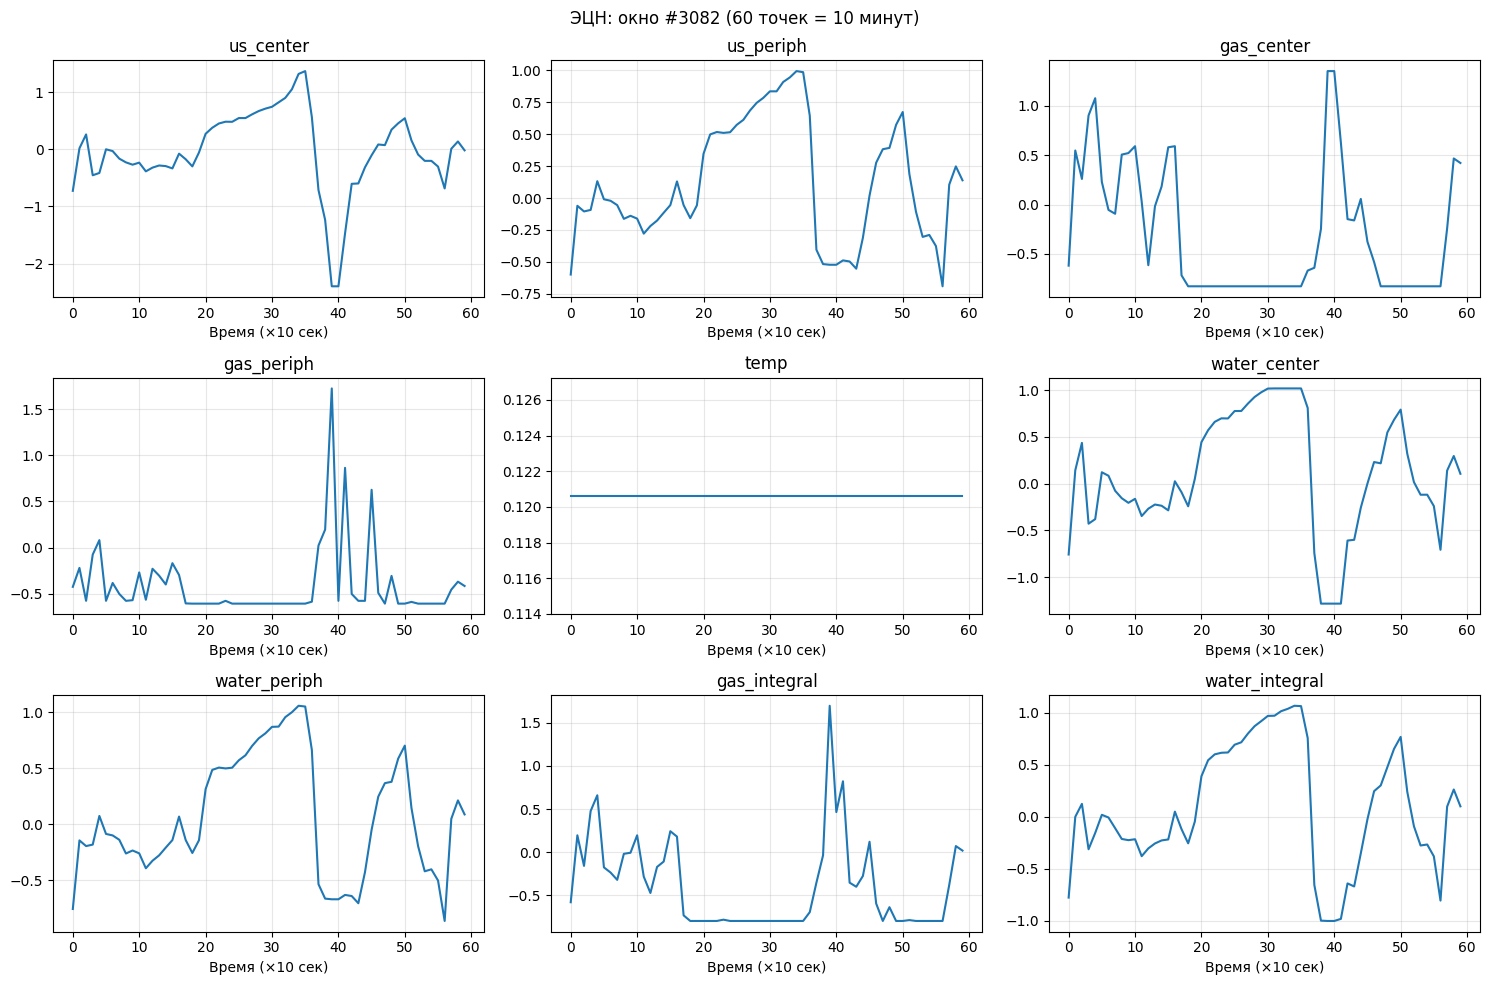

In [25]:
plot_random_window(X_ecn_train, FEATURE_COLUMNS, WINDOW_SIZE_ECN, "ЭЦН")

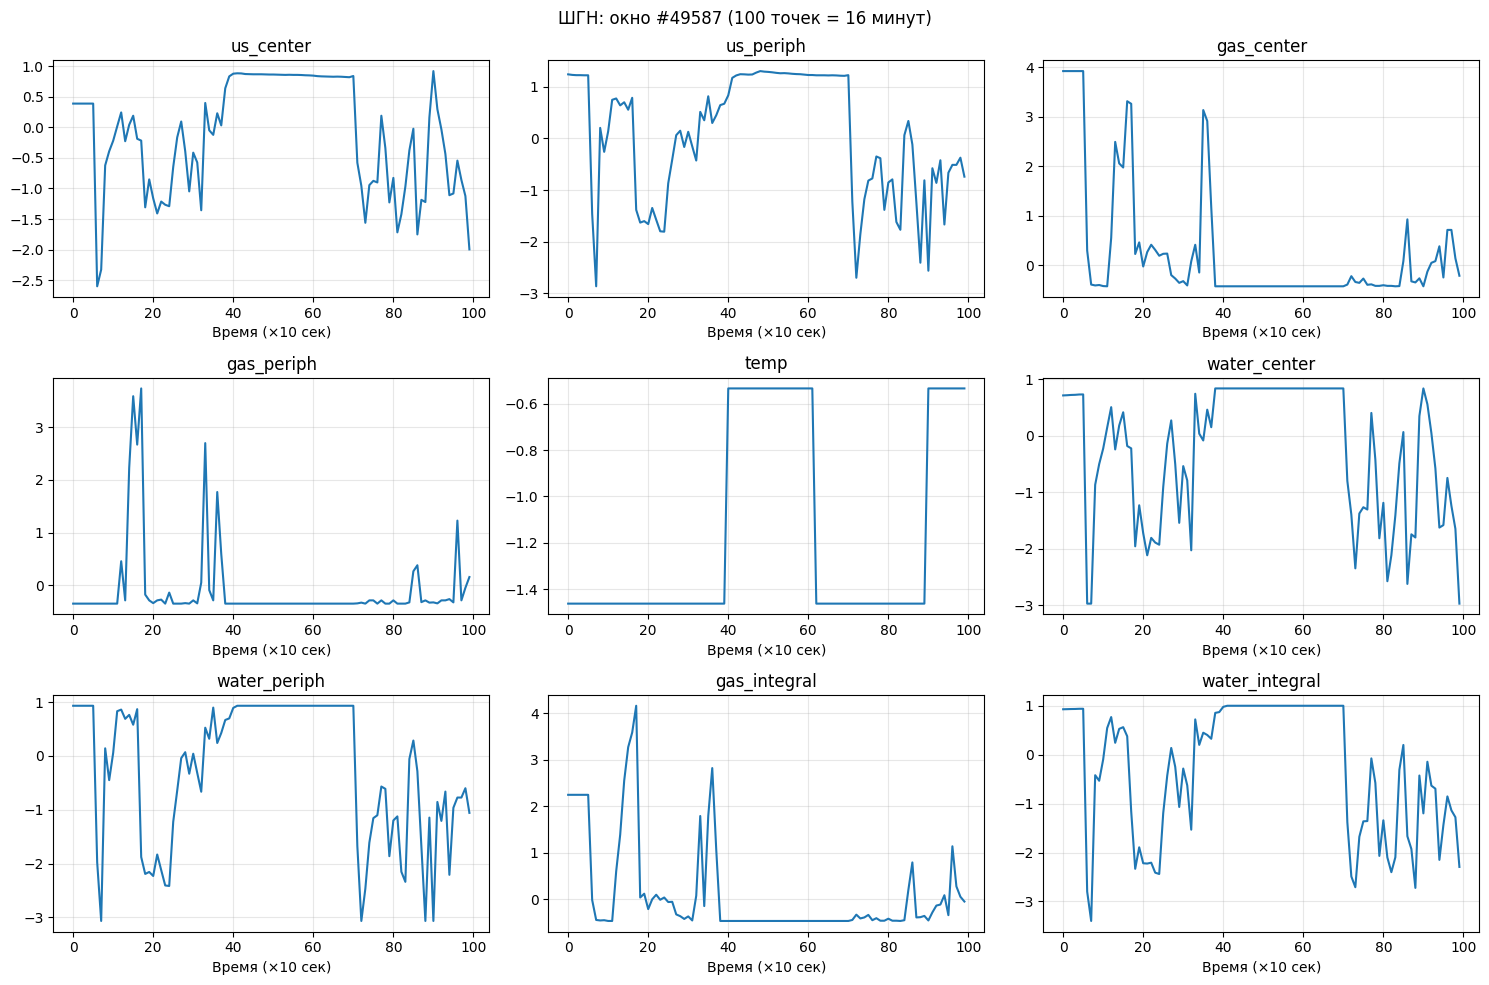

In [26]:
plot_random_window(X_shgn_train, FEATURE_COLUMNS, WINDOW_SIZE_SHGN, "ШГН")

### 3. Подготовка данных для PyTorch

In [27]:
BATCH_SIZE = 128

def make_dataloaders(X_train, X_val, X_test, batch_size=BATCH_SIZE):
    train_tensor = torch.from_numpy(X_train).float()
    val_tensor = torch.from_numpy(X_val).float()
    test_tensor = torch.from_numpy(X_test).float()

    train_ds = TensorDataset(train_tensor)
    val_ds = TensorDataset(val_tensor)
    test_ds = TensorDataset(test_tensor)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=False)

    return train_loader, val_loader, test_loader

In [29]:
ecn_train_loader, ecn_val_loader, ecn_test_loader = make_dataloaders(X_ecn_train, X_ecn_val, X_ecn_test)

shgn_train_loader, shgn_val_loader, shgn_test_loader = make_dataloaders(X_shgn_train, X_shgn_val, X_shgn_test)

print("DataLoaders ЭЦН:")
for name, loader in [("train", ecn_train_loader), ("val", ecn_val_loader), ("test", ecn_test_loader)]:
    x0 = next(iter(loader))[0]
    print(f"  {name}: batches={len(loader)}, batch_shape={x0.shape}")

print("\nDataLoaders ШГН:")
for name, loader in [("train", shgn_train_loader), ("val", shgn_val_loader), ("test", shgn_test_loader)]:
    x0 = next(iter(loader))[0]
    print(f"  {name}: batches={len(loader)}, batch_shape={x0.shape}")

DataLoaders ЭЦН:
  train: batches=261, batch_shape=torch.Size([128, 60, 9])
  val: batches=33, batch_shape=torch.Size([128, 60, 9])
  test: batches=33, batch_shape=torch.Size([128, 60, 9])

DataLoaders ШГН:
  train: batches=645, batch_shape=torch.Size([128, 100, 9])
  val: batches=80, batch_shape=torch.Size([128, 100, 9])
  test: batches=81, batch_shape=torch.Size([128, 100, 9])


### 4. Сравнение архитектур автоэнкодеров

Для выбора архитектуры автоэнкодера используем единый протокол оценки:

- **Общие условия обучения**
  - одинаковая предобработка данных (окна 60×9 для ЭЦН и 100×9 для ШГН);
  - одинаковые train/val/test разбиения;
  - одинаковые базовые гиперпараметры: размер латентного пространства, размер скрытого слоя, оптимизатор (Adam), скорость обучения, размер батча и число эпох.

- **Основной критерий**
  - средняя ошибка реконструкции на валидационной выборке (**val MSE**):
    - на train обучаем модель восстанавливать окно «само из себя»;
    - на val считаем средний MSE по всем окнам;
    - лучшая архитектура — та, у которой минимальный `val_loss` при сопоставимой сложности сети.

- **Дополнительный анализ**
  - сравнение динамики `train_loss` / `val_loss` по эпохам (раннее переобучение = архитектура неудачна);
  - сравнение распределения ошибки реконструкции для train и val (гистограммы / KDE): хорошая модель даёт близкие распределения без «длинных хвостов» на val.

В сравнении участвуют три архитектуры:

1. **LSTM‑автоэнкодер**  
   - последовательно кодирует окно LSTM‑слоями в латентный вектор фиксированной размерности;  
   - декодер — LSTM, восстанавливающий исходную последовательность по латентному представлению.

2. **GRU‑автоэнкодер**  
   - архитектурно аналогичен LSTM‑автоэнкодеру, но использует GRU‑ячейки (меньше параметров и быстрее обучение);  
   - обучается и оценивается в тех же условиях, что и LSTM‑модель.

3. **TCN‑автоэнкодер (Temporal Convolutional Network)**  
   - энкодер — несколько 1D‑сверточных слоёв с дилатацией (TCN), обрабатывающих последовательность по времени и сжимающих её в латентный вектор;  
   - декодер — обратная TCN‑структура (транспонированные/обычные свёртки с upsampling), восстанавливающая временной ряд.

Все архитектуры используют **одно и то же размерность латентного пространства и одинаковые базовые гиперпараметры** на этапе сравнения. После выбора лучшей архитектуры её гиперпараметры могут быть дополнительно уточнены (tuning) и финальная модель дообучается на полном тренировочном наборе.

In [ ]:
RANDOM_SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 128
N_EPOCHS = 30
LR = 1e-4
LR_SCHEDULER_PATIENCE = 3
LR_SCHEDULER_FACTOR = 0.5
LR_SCHEDULER_MIN_LR = 1e-6
WEIGHT_DECAY = 0.0

HIDDEN_SIZE = 64
LATENT_DIMS = [3, 4, 5, 6, 7, 8]

TRAIN_FRACTION_FOR_SEARCH = 0.2

RNN_NUM_LAYERS = 2
RNN_DROPOUT = 0.2

TCN_NUM_LAYERS = 3
TCN_KERNEL_SIZE = 3
TCN_DILATION_BASE = 2
TCN_DROPOUT = 0.2

MAX_GRAD_NORM = 1.0

torch.manual_seed(RANDOM_SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(RANDOM_SEED)

In [85]:
def subsample_windows(X, fraction, seed=42):
    n = X.shape[0]
    n_sub = max(1, int(n * fraction))

    rng = np.random.default_rng(seed)
    indices = rng.choice(n, size=n_sub, replace=False)
    indices = np.sort(indices)

    return X[indices]

In [89]:
X_ecn_train_sub = subsample_windows(X_ecn_train, TRAIN_FRACTION_FOR_SEARCH, RANDOM_SEED)
X_shgn_train_sub = subsample_windows(X_shgn_train, TRAIN_FRACTION_FOR_SEARCH, RANDOM_SEED)

ecn_train_loader_sub, ecn_val_loader_sub, _ = make_dataloaders(X_ecn_train_sub, X_ecn_val, X_ecn_test)
shgn_train_loader_sub, shgn_val_loader_sub, _ = make_dataloaders(X_shgn_train_sub, X_shgn_val, X_shgn_test)

**LSTM‑автоэнкодер.**  
Входное окно размерности (в нашем случае (T=60/100), (F=9)) подаётся в LSTM‑энкодер.  
Последнее скрытое состояние LSTM сжимается полносвязным слоем в латентный вектор фиксированной размерности `latent_dim`.  
Декодер инициализируется этим латентным вектором (через обратное отображение в скрытое состояние) и с нулевым входом по времени восстанавливает всю последовательность, после чего к каждому шагу применяется линейный слой для реконструкции признаков. Таким образом, модель учится кодировать окно во вектор и восстанавливать его обратно.

**GRU‑автоэнкодер.**  
Архитектура полностью аналогична LSTM‑автоэнкодеру, но в качестве рекуррентных ячеек используются GRU.  
Это уменьшает число параметров и ускоряет обучение при сохранении способности моделировать временные зависимости.  
Как и в LSTM‑варианте, энкодер GRU сжимает окно в латентный вектор, а декодер GRU, инициализированный этим вектором, по нулевому входу генерирует реконструированную последовательность.

**TCN‑автоэнкодер (Temporal Convolutional Network).**  
Этот вариант тоже обрабатывает окно как временной сигнал, но вместо рекуррентных слоёв (LSTM/GRU) использует 1D‑свёртки по времени.  
В энкодере несколько свёрточных слоёв, которые «смотрят» на всё более длинные отрезки временного ряда (за счёт увеличения шага свёртки). Так сеть учится видеть как быстрые, так и более долгие колебания в данных.  
Получившийся набор свёрточных признаков сжимается в компактное латентное представление фиксированного размера.  
Декодер — это те же свёртки, но «в обратную сторону»: по латентному представлению он восстанавливает исходную форму сигнала. На выходе получаем такое же по длине окно, как и на входе.

In [90]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_size, latent_dim, seq_len, num_layers=RNN_NUM_LAYERS):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_size = hidden_size
        self.latent_dim = latent_dim
        self.seq_len = seq_len
        self.num_layers = num_layers

        self.encoder_lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=RNN_DROPOUT if num_layers > 1 else 0.0,
        )
        self.fc_enc = nn.Linear(hidden_size, latent_dim)

        self.fc_dec = nn.Linear(latent_dim, hidden_size)
        self.decoder_lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=RNN_DROPOUT if num_layers > 1 else 0.0,
        )
        self.output_layer = nn.Linear(hidden_size, input_dim)

    def encode(self, x):
        _, (h_n, _) = self.encoder_lstm(x)
        h_last = h_n[-1]
        z = self.fc_enc(h_last)
        return z

    def decode(self, z, seq_len=None):
        if seq_len is None:
            seq_len = self.seq_len

        B = z.size(0)
        device = z.device

        h0 = self.fc_dec(z)
        h0 = h0.unsqueeze(0).repeat(self.num_layers, 1, 1)
        c0 = torch.zeros_like(h0)

        dec_input = torch.zeros(B, seq_len, self.input_dim, device=device)
        dec_output, _ = self.decoder_lstm(dec_input, (h0, c0))
        recon = self.output_layer(dec_output)
        return recon

    def forward(self, x):
        z = self.encode(x)
        recon = self.decode(z, seq_len=x.size(1))
        return recon

In [93]:
class GRUAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_size, latent_dim, seq_len, num_layers=RNN_NUM_LAYERS):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_size = hidden_size
        self.latent_dim = latent_dim
        self.seq_len = seq_len
        self.num_layers = num_layers

        self.encoder_gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=RNN_DROPOUT if num_layers > 1 else 0.0,
        )
        self.fc_enc = nn.Linear(hidden_size, latent_dim)

        self.fc_dec = nn.Linear(latent_dim, hidden_size)
        self.decoder_gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=RNN_DROPOUT if num_layers > 1 else 0.0,
        )
        self.output_layer = nn.Linear(hidden_size, input_dim)

    def encode(self, x):
        _, h_n = self.encoder_gru(x)
        h_last = h_n[-1]
        z = self.fc_enc(h_last)
        return z

    def decode(self, z, seq_len=None):
        if seq_len is None:
            seq_len = self.seq_len

        B = z.size(0)
        device = z.device

        h0 = self.fc_dec(z)
        h0 = h0.unsqueeze(0).repeat(self.num_layers, 1, 1)

        dec_input = torch.zeros(B, seq_len, self.input_dim, device=device)
        dec_output, _ = self.decoder_gru(dec_input, h0)
        recon = self.output_layer(dec_output)
        return recon

    def forward(self, x):
        z = self.encode(x)
        recon = self.decode(z, seq_len=x.size(1))
        return recon

In [94]:
class CausalConv1d(nn.Conv1d):
    def forward(self, x):
        pad = (self.kernel_size[0] - 1) * self.dilation[0]
        x = F.pad(x, (pad, 0))
        return super().forward(x)


class TemporalBlock(nn.Module):
    def __init__(self, n_in, n_out, kernel_size, stride, dilation, dropout=0.2):
        super().__init__()
        self.conv1 = CausalConv1d(n_in, n_out, kernel_size, stride=stride, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(n_out)
        self.act1 = nn.PReLU(num_parameters=n_out)
        self.drop1 = nn.Dropout(dropout)

        self.conv2 = CausalConv1d(n_out, n_out, kernel_size, stride=stride, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(n_out)
        self.act2 = nn.PReLU(num_parameters=n_out)
        self.drop2 = nn.Dropout(dropout)

        self.downsample = nn.Conv1d(n_in, n_out, 1) if n_in != n_out else None
        self.final_act = nn.PReLU(num_parameters=n_out)

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_normal_(self.conv1.weight, mode="fan_in", nonlinearity="linear")
        nn.init.kaiming_normal_(self.conv2.weight, mode="fan_in", nonlinearity="linear")

    def forward(self, x):
        res = x if self.downsample is None else self.downsample(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.act1(out)
        out = self.drop1(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.act2(out)
        out = self.drop2(out)
        return self.final_act(out + res)


class TCNAutoencoder(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_size,
        latent_dim,
        seq_len,
        num_layers=TCN_NUM_LAYERS,
        kernel_size=TCN_KERNEL_SIZE,
        dilation_base=TCN_DILATION_BASE,
        dropout=TCN_DROPOUT,
    ):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_size = hidden_size
        self.latent_dim = latent_dim
        self.seq_len = seq_len

        hidden_channels = [hidden_size] * num_layers
        enc_layers = []
        for i, ch in enumerate(hidden_channels):
            n_in = input_dim if i == 0 else hidden_channels[i - 1]
            dilation = dilation_base**i
            enc_layers.append(
                TemporalBlock(
                    n_in,
                    ch,
                    kernel_size=kernel_size,
                    stride=1,
                    dilation=dilation,
                    dropout=dropout,
                )
            )
        self.encoder = nn.Sequential(*enc_layers)
        self.projection = nn.Conv1d(hidden_channels[-1], latent_dim, kernel_size=1)

        dec_channels = hidden_channels[::-1]
        dec_layers = [TemporalBlock(latent_dim, dec_channels[0], kernel_size, 1, 1, dropout)]
        for i in range(1, len(dec_channels)):
            dilation = dilation_base**i
            dec_layers.append(
                TemporalBlock(
                    dec_channels[i - 1],
                    dec_channels[i],
                    kernel_size,
                    1,
                    dilation,
                    dropout,
                )
            )
        self.decoder = nn.Sequential(*dec_layers)
        self.recon_layer = nn.Conv1d(dec_channels[-1], input_dim, kernel_size=1)

    def encode(self, x):
        x = x.transpose(1, 2)
        feat = self.encoder(x)
        latent = self.projection(feat)
        return latent

    def decode(self, latent, seq_len=None):
        if seq_len is None:
            seq_len = self.seq_len
        dec_feat = self.decoder(latent)
        recon = self.recon_layer(dec_feat)
        recon = recon.transpose(1, 2)
        return recon

    def forward(self, x):
        latent = self.encode(x)
        recon = self.decode(latent, seq_len=x.size(1))
        return recon